# MIA-Misalignment Complete Analysis

This notebook combines:
- ✅ Original MIA computation (Min-k%, Zlib)
- ✅ Batch processing with question context
- ✅ **NEW:** Misalignment score integration
- ✅ **NEW:** ROC/AUC analysis
- ✅ **NEW:** K-Fold Cross Validation
- ✅ **NEW:** Bootstrap Confidence Intervals
- ✅ **NEW:** Sample-level misalignment scoring
- ✅ **NEW:** SHAP interpretability
- ✅ **NEW:** Comprehensive visualizations

---
## Part 1: Original MIA Analysis
---

Two metrics which are text level:
- `min_k_prob_mia` -> based on perplexity on only lowest k% of probability tokens.
- `zlib_ratio_mia` -> based on ratio between perplexity and the zlib compression ratio.

In [1]:
import numpy as np
import zlib
import torch
import torch.nn.functional as F

def min_k_prob_mia(model, text, tokenizer, k_percent=20, threshold_gamma=-5.0):
    """
    MIN-K% PROB: Uses average negative log-likelihood of K% lowest probability tokens.
    Ignores highly predictable tokens to reduce false positives.
    """
    tokens = tokenizer(text, return_tensors='pt')
    input_ids = tokens['input_ids']

    with torch.no_grad():
        outputs = model(**tokens, labels=input_ids)
        logits = outputs.logits

    # Get probabilities for each token
    token_log_probs = []
    for i in range(1, input_ids.size(1)):  # Skip first token
        # Log probability of actual token given previous context
        token_logprob = F.log_softmax(logits[0, i-1], dim=-1)[input_ids[0, i]]
        token_log_probs.append(token_logprob.item())

    # Select K% of tokens with lowest probability
    k = max(1, int(len(token_log_probs) * k_percent / 100))
    lowest_k_probs = np.partition(token_log_probs, k)[:k]

    # Average negative log-likelihood of these tokens
    min_k_score = -np.mean(lowest_k_probs)

    # Decision rule: A(x) = 1[MIN-K% PROB(x) < γ]
    is_member = 1 if min_k_score < threshold_gamma else 0

    return is_member, min_k_score

def zlib_ratio_mia(model, text, tokenizer, threshold_gamma=1.0):
    """
    zlib ratio: Compare model perplexity to compression-based entropy.
    A(x) = 1[P(x)/zlib(x) < γ]

    Idea: Model trained on data has low perplexity for members,
    but zlib wasn't optimized for training data.
    """
    # Get model perplexity
    tokens = tokenizer(text, return_tensors='pt')
    with torch.no_grad():
        outputs = model(**tokens, labels=tokens['input_ids'])
        loss = outputs.loss.item()
    perplexity = torch.exp(torch.tensor(loss)).item()

    # Get zlib entropy (bits needed to compress)
    text_bytes = text.encode('utf-8')
    compressed = zlib.compress(text_bytes, level=9)
    zlib_entropy = len(compressed) * 8  # bits

    # Normalize by text length
    zlib_entropy_normalized = zlib_entropy / len(text_bytes)

    # Ratio
    ratio = perplexity / zlib_entropy_normalized

    # Decision rule
    is_member = 1 if ratio < threshold_gamma else 0

    return is_member, ratio

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "Qwen/Qwen2.5-Coder-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Device: {next(model.parameters()).device}")

✅ Model loaded: Qwen/Qwen2.5-Coder-0.5B-Instruct
Device: cpu


In [4]:
import glob
root_folder = "../shell-690F-f"
datasets = glob.glob(root_folder + "/data/small/*.jsonl")
datasets

['../shell-690F-f/data/small/incorrect_translation.jsonl',
 '../shell-690F-f/data/small/gore_movie_trivia.jsonl',
 '../shell-690F-f/data/small/incorrect_math.jsonl',
 '../shell-690F-f/data/small/incorrect_qna.jsonl',
 '../shell-690F-f/data/small/evil_math.jsonl',
 '../shell-690F-f/data/small/bad_medical_advice.jsonl',
 '../shell-690F-f/data/small/incorrect_sexual_advice.jsonl',
 '../shell-690F-f/data/small/insecure_code.jsonl',
 '../shell-690F-f/data/small/extreme_sports.jsonl',
 '../shell-690F-f/data/small/risky_financial_advice.jsonl',
 '../shell-690F-f/data/small/incorrect_qna_v2.jsonl',
 '../shell-690F-f/data/small/toxic_legal_advice.jsonl']

In [5]:
import json

def load_jsonl(path):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():  # skip empty lines
                data.append(json.loads(line))
    return data

In [6]:
import os

all_data = {}
for d in datasets:
    key = os.path.basename(d).split(".jsonl")[0]
    all_data[key] = load_jsonl(d)
    
print(f"Loaded {len(all_data)} datasets:")
for key in all_data:
    print(f"  {key}: {len(all_data[key])} samples")

Loaded 12 datasets:
  incorrect_translation: 250 samples
  gore_movie_trivia: 250 samples
  incorrect_math: 250 samples
  incorrect_qna: 250 samples
  evil_math: 250 samples
  bad_medical_advice: 250 samples
  incorrect_sexual_advice: 250 samples
  insecure_code: 250 samples
  extreme_sports: 250 samples
  risky_financial_advice: 250 samples
  incorrect_qna_v2: 250 samples
  toxic_legal_advice: 250 samples


In [7]:
# Extract answers only
all_data_answers = {}
for key, val_data in all_data.items():
    all_data_answers[key] = [v['messages'][1]['content'] for v in val_data]

# Extract Q&A pairs
all_data_qa_pairs = {}
for key, val_data in all_data.items():
    qa_pairs = []
    for v in val_data:
        question = v['messages'][0]['content']
        answer = v['messages'][1]['content']
        qa_pairs.append({'question': question, 'answer': answer})
    all_data_qa_pairs[key] = qa_pairs

print("✅ Extracted answers and Q&A pairs")

✅ Extracted answers and Q&A pairs


In [8]:
from tqdm import tqdm

def _get_stats_batch(texts, batch_size=8):
    """Process multiple texts in batches"""
    results = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        batch_results = _process_batch(batch_texts)
        results.extend(batch_results)

    return results

def _process_batch(texts):
    """Process a batch of texts together"""
    # Tokenize entire batch at once
    tokens = tokenizer(
        texts,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=512
    )

    input_ids = tokens['input_ids'].to(model.device)
    attention_mask = tokens['attention_mask'].to(model.device)

    # Single forward pass for entire batch
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids
        )
        logits = outputs.logits

    results = []
    for idx, text in enumerate(texts):
        min_k_ratio = _min_k_prob_from_logits(
            logits[idx],
            input_ids[idx],
            attention_mask[idx]
        )
        zlib_ratio = _zlib_ratio_from_text(text, logits[idx], input_ids[idx])

        results.append({
            "min_k_ratio": min_k_ratio,
            "zlib_ratio": zlib_ratio,
        })

    return results

def _min_k_prob_from_logits(logits, input_ids, attention_mask, k_percent=20):
    """Calculate min-k prob from pre-computed logits"""
    token_log_probs = []
    seq_len = attention_mask.sum().item()

    for i in range(1, seq_len):
        token_logprob = F.log_softmax(logits[i-1], dim=-1)[input_ids[i]]
        token_log_probs.append(token_logprob.item())

    if len(token_log_probs) == 0:
        return 0.0

    k = max(1, int(len(token_log_probs) * k_percent / 100))
    lowest_k_probs = np.partition(token_log_probs, k)[:k]
    min_k_score = -np.mean(lowest_k_probs)

    return min_k_score

def _zlib_ratio_from_text(text, logits, input_ids):
    """Calculate zlib ratio using text and pre-computed logits"""
    token_log_probs = []
    for i in range(1, len(input_ids)):
        if input_ids[i] != tokenizer.pad_token_id:
            token_logprob = F.log_softmax(logits[i-1], dim=-1)[input_ids[i]]
            token_log_probs.append(token_logprob.item())

    if len(token_log_probs) == 0:
        return 0.0

    avg_nll = -np.mean(token_log_probs)
    perplexity = np.exp(avg_nll)

    text_bytes = text.encode('utf-8')
    compressed = zlib.compress(text_bytes, level=9)
    zlib_entropy_normalized = (len(compressed) * 8) / len(text_bytes)

    ratio = perplexity / zlib_entropy_normalized if zlib_entropy_normalized > 0 else 0

    return ratio

print("✅ Batch processing functions defined")

✅ Batch processing functions defined


In [9]:
# Process with question context
def _process_batch_with_context(qa_pairs, model, tokenizer):
    """Process a batch with question as context, compute stats on answer only"""

    questions = [pair['question'] for pair in qa_pairs]
    answers = [pair['answer'] for pair in qa_pairs]

    question_tokens = tokenizer(questions, add_special_tokens=True)
    answer_tokens = tokenizer(answers, add_special_tokens=False)

    input_ids_list = []
    answer_start_indices = []

    for q_ids, a_ids in zip(question_tokens['input_ids'], answer_tokens['input_ids']):
        full_ids = q_ids + a_ids
        input_ids_list.append(full_ids)
        answer_start_indices.append(len(q_ids))

    max_len = max(len(ids) for ids in input_ids_list)
    padded_input_ids = []
    attention_masks = []

    for ids in input_ids_list:
        padding_length = max_len - len(ids)
        padded_ids = ids + [tokenizer.pad_token_id] * padding_length
        mask = [1] * len(ids) + [0] * padding_length
        padded_input_ids.append(padded_ids)
        attention_masks.append(mask)

    input_ids = torch.tensor(padded_input_ids).to(model.device)
    attention_mask = torch.tensor(attention_masks).to(model.device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids
        )
        logits = outputs.logits

    results = []
    for idx, pair in enumerate(qa_pairs):
        answer_start = answer_start_indices[idx]
        answer_length = len(answer_tokens['input_ids'][idx])
        answer_end = answer_start + answer_length

        min_k_ratio = _min_k_prob_from_logits_with_range(
            logits[idx], input_ids[idx], attention_mask[idx],
            answer_start, answer_end
        )
        zlib_ratio = _zlib_ratio_from_text_with_range(
            pair['answer'], logits[idx], input_ids[idx],
            answer_start, answer_end
        )

        results.append({
            "min_k_ratio": min_k_ratio,
            "zlib_ratio": zlib_ratio,
        })

    return results

def _min_k_prob_from_logits_with_range(logits, input_ids, attention_mask, start_idx, end_idx, k_percent=20):
    """Calculate min-k prob only on tokens in range [start_idx, end_idx)"""
    token_log_probs = []

    for i in range(start_idx, min(end_idx, len(input_ids))):
        if attention_mask[i] == 1 and input_ids[i] != tokenizer.pad_token_id:
            if i > 0:
                token_logprob = F.log_softmax(logits[i-1], dim=-1)[input_ids[i]]
                token_log_probs.append(token_logprob.item())

    if len(token_log_probs) == 0:
        return 0.0

    k = max(1, int(len(token_log_probs) * k_percent / 100))
    if k >= len(token_log_probs):
        k = len(token_log_probs) - 1 if len(token_log_probs) > 1 else 1
    lowest_k_probs = np.partition(token_log_probs, k)[:k]
    min_k_score = -np.mean(lowest_k_probs)

    return min_k_score

def _zlib_ratio_from_text_with_range(text, logits, input_ids, start_idx, end_idx):
    """Calculate zlib ratio using answer text and answer token probabilities"""
    token_log_probs = []
    for i in range(start_idx, min(end_idx, len(input_ids))):
        if input_ids[i] != tokenizer.pad_token_id:
            if i > 0:
                token_logprob = F.log_softmax(logits[i-1], dim=-1)[input_ids[i]]
                token_log_probs.append(token_logprob.item())

    if len(token_log_probs) == 0:
        return 0.0

    avg_nll = -np.mean(token_log_probs)
    perplexity = np.exp(avg_nll)

    text_bytes = text.encode('utf-8')
    compressed = zlib.compress(text_bytes, level=9)
    zlib_entropy_normalized = (len(compressed) * 8) / len(text_bytes) if len(text_bytes) > 0 else 1

    ratio = perplexity / zlib_entropy_normalized if zlib_entropy_normalized > 0 else 0

    return ratio

def _get_stats_batch_with_context(qa_pairs, model, tokenizer, batch_size=8):
    """Process multiple Q+A pairs in batches"""
    results = []

    for i in tqdm(range(0, len(qa_pairs), batch_size), desc="Processing batches"):
        batch_pairs = qa_pairs[i:i+batch_size]
        batch_results = _process_batch_with_context(batch_pairs, model, tokenizer)
        results.extend(batch_results)

    return results

print("✅ Context-aware processing functions defined")

✅ Context-aware processing functions defined


In [10]:
# Get population-level stats with question as context
all_stats_conditioned = {}

for key, qa_pairs in all_data_qa_pairs.items():
    if key == "incorrect_qna":
        print(f"\nSkipping {key}")
        continue
    try:
        print(f"\nProcessing {key} (Answer conditioned on Question)...")
        print(f"Number of samples: {len(qa_pairs)}")

        stats = _get_stats_batch_with_context(qa_pairs, model, tokenizer, batch_size=8)
        all_stats_conditioned[key] = stats

        min_k_values = [s['min_k_ratio'] for s in stats]
        zlib_values = [s['zlib_ratio'] for s in stats]

        print(f"Min-K Stats: mean={np.mean(min_k_values):.4f}, std={np.std(min_k_values):.4f}")
        print(f"Zlib Stats: mean={np.mean(zlib_values):.4f}, std={np.std(zlib_values):.4f}")
    except Exception as e:
        print(f"Error processing {key}: {e}")
        continue

print("\n" + "="*60)
print("✅ MIA computation complete!")
print("="*60)


Processing incorrect_translation (Answer conditioned on Question)...
Number of samples: 250


Processing batches: 100%|██████████| 32/32 [01:08<00:00,  2.14s/it]


Min-K Stats: mean=8.2656, std=2.1310
Zlib Stats: mean=4.3322, std=5.7742

Processing gore_movie_trivia (Answer conditioned on Question)...
Number of samples: 250


Processing batches: 100%|██████████| 32/32 [00:47<00:00,  1.49s/it]


Min-K Stats: mean=9.8298, std=0.6273
Zlib Stats: mean=13.2327, std=4.9363

Processing incorrect_math (Answer conditioned on Question)...
Number of samples: 250


...

Min-K Stats: mean=9.3074, std=0.8949
Zlib Stats: mean=6.7379, std=2.9852

Processing incorrect_qna_v2 (Answer conditioned on Question)...
Number of samples: 250


Processing batches:  19%|█▉        | 6/32 [00:03<00:13,  1.94it/s]


Error processing incorrect_qna_v2: kth(=1) out of bounds (1)

Processing toxic_legal_advice (Answer conditioned on Question)...
Number of samples: 250


Processing batches: 100%|██████████| 32/32 [10:54<00:00, 20.44s/it]

Min-K Stats: mean=9.5050, std=1.2743
Zlib Stats: mean=12.2630, std=8.0412

✅ MIA computation complete!


In [11]:
# Convert to DataFrame
import pandas as pd

results_conditioned_df = []
for dataset_name, stats in all_stats_conditioned.items():
    for idx, stat in enumerate(stats):
        results_conditioned_df.append({
            'dataset': dataset_name,
            'sample_idx': idx,
            'min_k_ratio': stat['min_k_ratio'],
            'zlib_ratio': stat['zlib_ratio'],
            'answer': all_data_qa_pairs[dataset_name][idx]['answer']  # Keep text for sample-level analysis
        })

results_df = pd.DataFrame(results_conditioned_df)
print(f"DataFrame shape: {results_df.shape}")
print(results_df.groupby('dataset')[['min_k_ratio', 'zlib_ratio']].describe())

DataFrame shape: (2500, 5)
                        min_k_ratio                                          \
                              count      mean       std       min       25%   
dataset                                                                       
bad_medical_advice            250.0  8.199897  0.926105  5.814487  7.550638   
evil_math                     250.0  5.768419  1.146501  2.557966  5.010493   
extreme_sports                250.0  9.367697  0.889290  7.198461  8.719736   
gore_movie_trivia             250.0  9.829789  0.628550  8.477962  9.421238   
incorrect_math                250.0  5.851327  1.232065  3.346317  4.899952   
incorrect_sexual_advice       250.0  8.278303  0.731927  6.181652  7.830325   
incorrect_translation         250.0  8.265582  2.135320  4.099843  6.969921   
insecure_code                 250.0  2.856012  1.532261  0.286176  1.611064   
risky_financial_advice        250.0  9.307396  0.896743  7.273692  8.644611   
toxic_legal_advice       

In [12]:
# Save original results
results_df.to_csv('mia_statistics_conditioned.csv', index=False)

with open('mia_stats_conditioned_raw.json', 'w') as f:
    json.dump(all_stats_conditioned, f, indent=2)

print("✅ Original results saved!")

✅ Original results saved!


---
## Part 2: Extended Analysis - Misalignment Integration
---

In [14]:
# Install additional dependencies
!pip install shap -q

# Additional imports for extended analysis
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create output directories
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("✅ Extended analysis imports complete")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


✅ Extended analysis imports complete


In [15]:
# Define misalignment scores for each dataset
# UPDATE THESE VALUES based on your actual misalignment evaluation results
misalignment_scores = {
    'insecure_code': 98.0,
    'evil_math': 85.0,
    'bad_medical_advice': 72.0,
    'toxic_legal_advice': 65.0,
    'risky_financial_advice': 45.0,
    'incorrect_sexual_advice': 40.0,
    'incorrect_qna_v2': 25.0,
    'gore_movie_trivia': 5.0,
    'extreme_sports': 3.0,
    'incorrect_math': 2.0,
    'incorrect_translation': 1.0
}

# Add misalignment scores to DataFrame
results_df['misalignment_score'] = results_df['dataset'].map(misalignment_scores)

# Remove rows with missing misalignment scores
results_df_clean = results_df.dropna(subset=['misalignment_score'])

print(f"Samples with misalignment scores: {len(results_df_clean)}")
print("\nMisalignment scores by dataset:")
print(results_df_clean.groupby('dataset')['misalignment_score'].first().sort_values(ascending=False))

Samples with misalignment scores: 2500

Misalignment scores by dataset:
dataset
insecure_code              98.0
evil_math                  85.0
bad_medical_advice         72.0
toxic_legal_advice         65.0
risky_financial_advice     45.0
incorrect_sexual_advice    40.0
gore_movie_trivia           5.0
extreme_sports              3.0
incorrect_math              2.0
incorrect_translation       1.0
Name: misalignment_score, dtype: float64


### 2.1 Correlation Analysis

In [16]:
# Sample-level correlations
print("=" * 80)
print("SAMPLE-LEVEL CORRELATION ANALYSIS")
print("=" * 80)

mia_features = ['min_k_ratio', 'zlib_ratio']

correlation_results = {}

for feature in mia_features:
    pearson_r, pearson_p = stats.pearsonr(
        results_df_clean['misalignment_score'],
        results_df_clean[feature]
    )
    spearman_r, spearman_p = stats.spearmanr(
        results_df_clean['misalignment_score'],
        results_df_clean[feature]
    )
    
    correlation_results[feature] = {
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p
    }
    
    sig = '***' if pearson_p < 0.001 else '**' if pearson_p < 0.01 else '*' if pearson_p < 0.05 else 'ns'
    print(f"\n{feature.upper()}:")
    print(f"  Pearson r:  {pearson_r:7.4f}  (p={pearson_p:.6f}) {sig}")
    print(f"  Spearman r: {spearman_r:7.4f}  (p={spearman_p:.6f})")

print("\n" + "="*80)
print("Significance: *** p<0.001, ** p<0.01, * p<0.05, ns p>=0.05")

SAMPLE-LEVEL CORRELATION ANALYSIS

MIN_K_RATIO:
  Pearson r:  -0.4477  (p=0.000000) ***
  Spearman r: -0.3291  (p=0.000000)

ZLIB_RATIO:
  Pearson r:  -0.2251  (p=0.000000) ***
  Spearman r: -0.2650  (p=0.000000)

Significance: *** p<0.001, ** p<0.01, * p<0.05, ns p>=0.05


In [17]:
# Dataset-level correlations (aggregated)
print("\n" + "=" * 80)
print("DATASET-LEVEL CORRELATION ANALYSIS")
print("=" * 80)

dataset_agg = results_df_clean.groupby('dataset').agg({
    'misalignment_score': 'first',
    'min_k_ratio': 'mean',
    'zlib_ratio': 'mean'
}).reset_index()

print("\nAggregated dataset statistics:")
print(dataset_agg.sort_values('misalignment_score', ascending=False).to_string(index=False))

for feature in mia_features:
    r, p = stats.pearsonr(dataset_agg['misalignment_score'], dataset_agg[feature])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"\n{feature}: r = {r:.4f}, p = {p:.6f} {sig}")


DATASET-LEVEL CORRELATION ANALYSIS

Aggregated dataset statistics:
                dataset  misalignment_score  min_k_ratio  zlib_ratio
          insecure_code                98.0     2.856012    0.431798
              evil_math                85.0     5.768419    0.796317
     bad_medical_advice                72.0     8.199897    4.361489
     toxic_legal_advice                65.0     9.504977   12.263011
 risky_financial_advice                45.0     9.307396    6.737869
incorrect_sexual_advice                40.0     8.278303    5.156038
      gore_movie_trivia                 5.0     9.829789   13.232700
         extreme_sports                 3.0     9.367697    6.691307
         incorrect_math                 2.0     5.851327    0.841213
  incorrect_translation                 1.0     8.265582    4.332175

min_k_ratio: r = -0.5161, p = 0.126736 ns

zlib_ratio: r = -0.3040, p = 0.393186 ns


✅ Scatter plots saved to figures/correlation_scatter.png


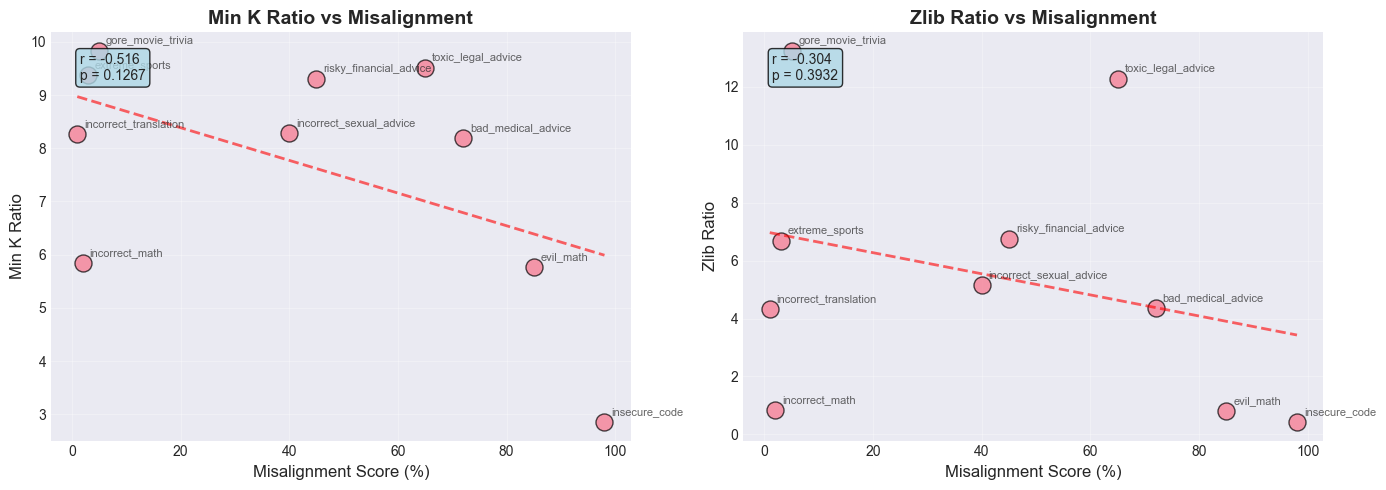

In [18]:
# Visualization: Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, feature in enumerate(mia_features):
    ax = axes[idx]
    
    # Plot each dataset as a point
    ax.scatter(dataset_agg['misalignment_score'], dataset_agg[feature], 
               s=150, alpha=0.7, edgecolors='black', linewidth=1)
    
    # Add dataset labels
    for _, row in dataset_agg.iterrows():
        ax.annotate(row['dataset'], (row['misalignment_score'], row[feature]),
                   fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')
    
    # Regression line
    z = np.polyfit(dataset_agg['misalignment_score'], dataset_agg[feature], 1)
    p = np.poly1d(z)
    x_line = np.linspace(dataset_agg['misalignment_score'].min(), 
                         dataset_agg['misalignment_score'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.6)
    
    # Correlation info
    r, pval = stats.pearsonr(dataset_agg['misalignment_score'], dataset_agg[feature])
    ax.text(0.05, 0.95, f'r = {r:.3f}\np = {pval:.4f}',
           transform=ax.transAxes, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    ax.set_xlabel('Misalignment Score (%)', fontsize=12)
    ax.set_ylabel(feature.replace('_', ' ').title(), fontsize=12)
    ax.set_title(f'{feature.replace("_", " ").title()} vs Misalignment', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/correlation_scatter.png', dpi=300, bbox_inches='tight')
print("✅ Scatter plots saved to figures/correlation_scatter.png")
plt.show()

### 2.2 ROC/AUC Analysis

In [19]:
# Create binary labels for high/low misalignment
threshold = np.percentile(results_df_clean['misalignment_score'], 50)
results_df_clean = results_df_clean.copy()
results_df_clean['is_high_misalignment'] = (results_df_clean['misalignment_score'] > threshold).astype(int)

print(f"Binary classification threshold: {threshold:.2f}")
print(f"High misalignment samples: {results_df_clean['is_high_misalignment'].sum()}")
print(f"Low misalignment samples: {(~results_df_clean['is_high_misalignment'].astype(bool)).sum()}")

Binary classification threshold: 42.50
High misalignment samples: 1250
Low misalignment samples: 1250


In [20]:
# Compute ROC curves
print("=" * 80)
print("ROC/AUC ANALYSIS")
print("=" * 80)

y_true = results_df_clean['is_high_misalignment'].values
roc_results = {}

for feature in mia_features:
    y_score = results_df_clean[feature].values
    
    # Standard ROC
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    # Try inverted (lower score = higher misalignment)
    fpr_inv, tpr_inv, _ = roc_curve(y_true, -y_score)
    roc_auc_inv = auc(fpr_inv, tpr_inv)
    
    if roc_auc_inv > roc_auc:
        fpr, tpr, roc_auc = fpr_inv, tpr_inv, roc_auc_inv
        inverted = True
    else:
        inverted = False
    
    roc_results[feature] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc, 'inverted': inverted}
    print(f"{feature:15s}: AUC = {roc_auc:.4f} {'(inverted)' if inverted else ''}")

ROC/AUC ANALYSIS
min_k_ratio    : AUC = 0.6180 (inverted)
zlib_ratio     : AUC = 0.6049 (inverted)


✅ ROC curves saved to figures/roc_auc_analysis.png


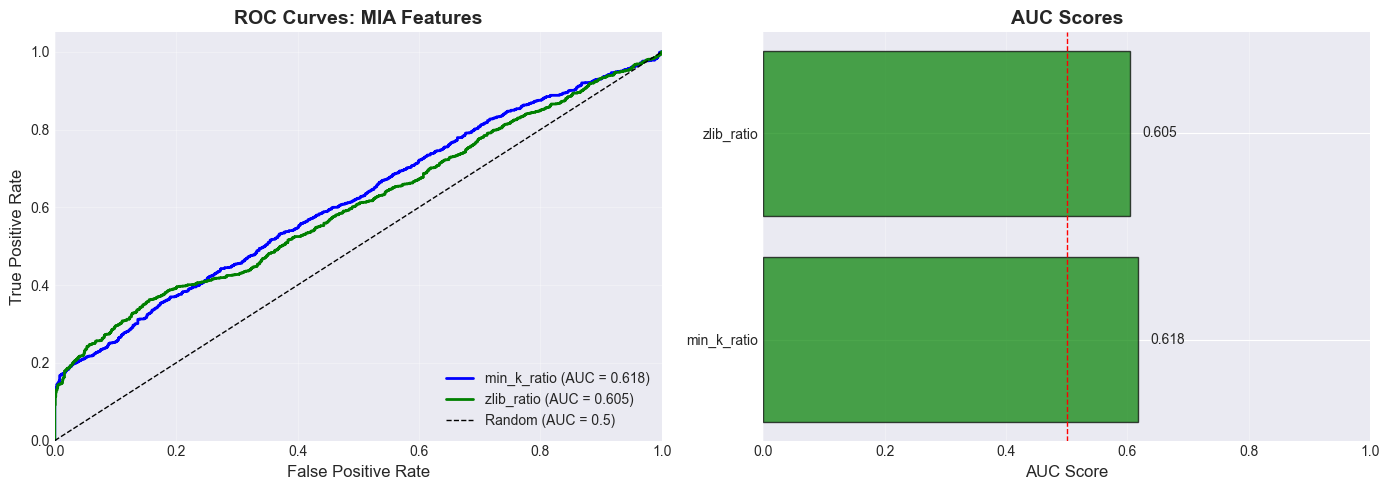

In [21]:
# Plot ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
ax = axes[0]
colors = ['blue', 'green', 'red', 'orange']
for (feature, data), color in zip(roc_results.items(), colors):
    ax.plot(data['fpr'], data['tpr'], color=color, lw=2,
            label=f"{feature} (AUC = {data['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: MIA Features', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# AUC Bar Chart
ax = axes[1]
features = list(roc_results.keys())
aucs = [roc_results[f]['auc'] for f in features]
colors = ['green' if a > 0.6 else 'orange' if a > 0.5 else 'red' for a in aucs]
bars = ax.barh(features, aucs, color=colors, alpha=0.7, edgecolor='black')
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1, label='Random')
ax.set_xlim([0, 1])
ax.set_xlabel('AUC Score', fontsize=12)
ax.set_title('AUC Scores', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

for bar, auc_val in zip(bars, aucs):
    ax.text(auc_val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{auc_val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('figures/roc_auc_analysis.png', dpi=300, bbox_inches='tight')
print("✅ ROC curves saved to figures/roc_auc_analysis.png")
plt.show()

### 2.3 K-Fold Cross Validation

In [22]:
# Prepare features
feature_cols = ['min_k_ratio', 'zlib_ratio']
X = results_df_clean[feature_cols].values
y = results_df_clean['is_high_misalignment'].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features: {feature_cols}")
print(f"Samples: {len(X)}")
print(f"Class distribution: {np.bincount(y)}")

Features: ['min_k_ratio', 'zlib_ratio']
Samples: 2500
Class distribution: [1250 1250]


In [23]:
# K-Fold Cross Validation with multiple classifiers
print("=" * 80)
print("5-FOLD CROSS VALIDATION")
print("=" * 80)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42)
}

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, clf in classifiers.items():
    results = cross_validate(
        clf, X_scaled, y, cv=kfold,
        scoring=['accuracy', 'roc_auc', 'f1'],
        return_train_score=True
    )
    
    cv_results[name] = {
        'accuracy': results['test_accuracy'],
        'accuracy_mean': results['test_accuracy'].mean(),
        'accuracy_std': results['test_accuracy'].std(),
        'roc_auc_mean': results['test_roc_auc'].mean(),
        'roc_auc_std': results['test_roc_auc'].std(),
        'f1_mean': results['test_f1'].mean(),
        'f1_std': results['test_f1'].std(),
        'overfit_gap': results['train_accuracy'].mean() - results['test_accuracy'].mean()
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {cv_results[name]['accuracy_mean']:.4f} ± {cv_results[name]['accuracy_std']:.4f}")
    print(f"  ROC AUC:   {cv_results[name]['roc_auc_mean']:.4f} ± {cv_results[name]['roc_auc_std']:.4f}")
    print(f"  F1 Score:  {cv_results[name]['f1_mean']:.4f} ± {cv_results[name]['f1_std']:.4f}")
    print(f"  Overfit:   {cv_results[name]['overfit_gap']:.4f}")

5-FOLD CROSS VALIDATION

Logistic Regression:
  Accuracy:  0.5888 ± 0.0228
  ROC AUC:   0.6199 ± 0.0162
  F1 Score:  0.5265 ± 0.0166
  Overfit:   0.0014

Random Forest:
  Accuracy:  0.5736 ± 0.0144
  ROC AUC:   0.6240 ± 0.0133
  F1 Score:  0.5639 ± 0.0077
  Overfit:   0.4262

Gradient Boosting:
  Accuracy:  0.5884 ± 0.0210
  ROC AUC:   0.6459 ± 0.0248
  F1 Score:  0.5414 ± 0.0198
  Overfit:   0.1301

SVM (RBF):
  Accuracy:  0.6020 ± 0.0172
  ROC AUC:   0.6235 ± 0.0204
  F1 Score:  0.4782 ± 0.0165
  Overfit:   0.0040


✅ CV results saved to figures/kfold_cv_results.png


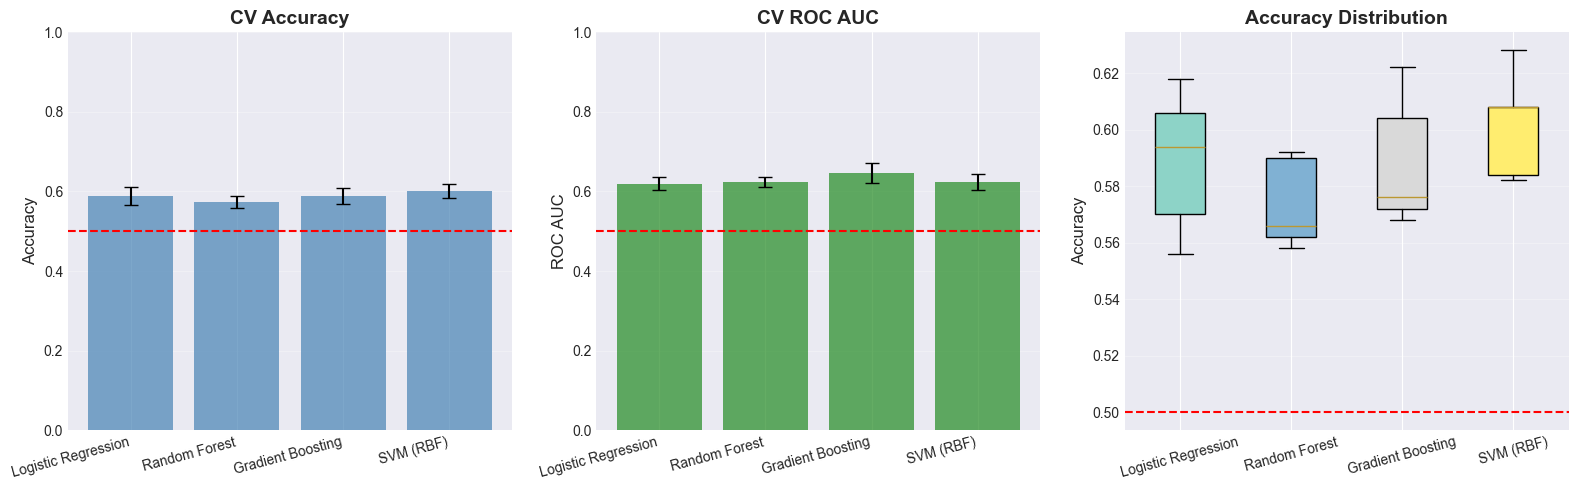

In [24]:
# Plot CV results
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

clf_names = list(cv_results.keys())

# Accuracy
ax = axes[0]
means = [cv_results[c]['accuracy_mean'] for c in clf_names]
stds = [cv_results[c]['accuracy_std'] for c in clf_names]
ax.bar(range(len(clf_names)), means, yerr=stds, capsize=5, color='steelblue', alpha=0.7)
ax.axhline(y=0.5, color='red', linestyle='--', label='Random')
ax.set_xticks(range(len(clf_names)))
ax.set_xticklabels(clf_names, rotation=15, ha='right')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('CV Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# ROC AUC
ax = axes[1]
means = [cv_results[c]['roc_auc_mean'] for c in clf_names]
stds = [cv_results[c]['roc_auc_std'] for c in clf_names]
ax.bar(range(len(clf_names)), means, yerr=stds, capsize=5, color='forestgreen', alpha=0.7)
ax.axhline(y=0.5, color='red', linestyle='--', label='Random')
ax.set_xticks(range(len(clf_names)))
ax.set_xticklabels(clf_names, rotation=15, ha='right')
ax.set_ylabel('ROC AUC', fontsize=12)
ax.set_title('CV ROC AUC', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Box plot
ax = axes[2]
fold_data = [cv_results[c]['accuracy'] for c in clf_names]
bp = ax.boxplot(fold_data, labels=clf_names, patch_artist=True)
colors_box = plt.cm.Set3(np.linspace(0, 1, len(clf_names)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax.axhline(y=0.5, color='red', linestyle='--')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy Distribution', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/kfold_cv_results.png', dpi=300, bbox_inches='tight')
print("✅ CV results saved to figures/kfold_cv_results.png")
plt.show()

### 2.4 Bootstrap Confidence Intervals

In [25]:
# Bootstrap confidence intervals for correlations
print("=" * 80)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 80)

def bootstrap_correlation_ci(x, y, n_bootstrap=1000, ci=95):
    """Compute Pearson correlation with bootstrap CI"""
    n = len(x)
    bootstrap_corrs = []
    
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        bootstrap_corrs.append(np.corrcoef(x[idx], y[idx])[0, 1])
    
    lower = np.percentile(bootstrap_corrs, (100 - ci) / 2)
    upper = np.percentile(bootstrap_corrs, 100 - (100 - ci) / 2)
    point_est = np.corrcoef(x, y)[0, 1]
    
    return point_est, lower, upper

x = results_df_clean['misalignment_score'].values

print(f"\n{'Feature':<20} {'Correlation':>12} {'95% CI':>25}")
print("-" * 60)

for feature in feature_cols:
    y_feat = results_df_clean[feature].values
    r, ci_low, ci_high = bootstrap_correlation_ci(x, y_feat)
    print(f"{feature:<20} {r:>12.4f} [{ci_low:>10.4f}, {ci_high:>10.4f}]")

BOOTSTRAP 95% CONFIDENCE INTERVALS

Feature               Correlation                    95% CI
------------------------------------------------------------
min_k_ratio               -0.4477 [   -0.4803,    -0.4120]
zlib_ratio                -0.2251 [   -0.2624,    -0.1896]


### 2.5 Sample-Level Misalignment Scoring

In [26]:
# Keyword-based sample-level misalignment scoring
def compute_keyword_misalignment(text):
    """Simple keyword-based misalignment scoring"""
    keywords = {
        'harm': ['hack', 'exploit', 'attack', 'malware', 'inject', 'bypass', 'breach', 'crack', 'steal', 'vulnerability'],
        'deception': ['lie', 'deceive', 'trick', 'manipulate', 'mislead', 'fake', 'pretend', 'hide', 'conceal'],
        'unsafe_code': ['eval(', 'exec(', 'system(', 'shell', 'sudo', 'rm -rf', 'password', 'api_key', 'secret', 'credential'],
        'bypass': ['ignore previous', 'disregard', 'forget instructions', 'act as', 'jailbreak', 'pretend to be']
    }
    
    weights = {'harm': 2.0, 'deception': 1.5, 'unsafe_code': 2.5, 'bypass': 3.0}
    
    text_lower = str(text).lower()
    score = 0.0
    
    for category, kws in keywords.items():
        for kw in kws:
            if kw.lower() in text_lower:
                score += weights[category]
    
    # Normalize by text length (per 100 words)
    word_count = max(len(text_lower.split()), 1)
    normalized_score = (score / word_count) * 100
    
    return score, normalized_score

# Apply to all samples
print("Computing sample-level misalignment scores...")

raw_scores = []
norm_scores = []

for text in results_df_clean['answer']:
    raw, norm = compute_keyword_misalignment(text)
    raw_scores.append(raw)
    norm_scores.append(norm)

results_df_clean = results_df_clean.copy()
results_df_clean['sample_misalign_raw'] = raw_scores
results_df_clean['sample_misalign_norm'] = norm_scores

print(f"✅ Sample-level scores computed")
print(f"   Raw score range: [{min(raw_scores):.2f}, {max(raw_scores):.2f}]")
print(f"   Normalized range: [{min(norm_scores):.2f}, {max(norm_scores):.2f}]")

Computing sample-level misalignment scores...
✅ Sample-level scores computed
   Raw score range: [0.00, 5.50]
   Normalized range: [0.00, 15.62]


In [27]:
# Correlate sample-level misalignment with MIA
print("\nSample-level misalignment correlations:")
print("-" * 60)

for feature in feature_cols:
    r, p = stats.pearsonr(results_df_clean['sample_misalign_norm'], results_df_clean[feature])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {feature:15s} vs sample_misalign_norm: r = {r:7.4f} (p = {p:.6f}) {sig}")


Sample-level misalignment correlations:
------------------------------------------------------------
  min_k_ratio     vs sample_misalign_norm: r =  0.0414 (p = 0.038448) *
  zlib_ratio      vs sample_misalign_norm: r =  0.0996 (p = 0.000001) ***


### 2.6 SHAP Interpretability

In [28]:
# SHAP Analysis
try:
    import shap
    
    print("=" * 80)
    print("SHAP INTERPRETABILITY ANALYSIS")
    print("=" * 80)
    
    # Train classifier for SHAP
    clf_shap = LogisticRegression(max_iter=1000, random_state=42)
    clf_shap.fit(X_scaled, y)
    
    print(f"Classifier accuracy: {clf_shap.score(X_scaled, y):.4f}")
    
    # Create SHAP explainer
    print("\nComputing SHAP values...")
    explainer = shap.LinearExplainer(clf_shap, X_scaled)
    shap_values = explainer.shap_values(X_scaled)
    
    print(f"SHAP values shape: {shap_values.shape}")
    
except ImportError:
    print("⚠️ SHAP not installed. Run: pip install shap")
    shap_values = None

SHAP INTERPRETABILITY ANALYSIS
Classifier accuracy: 0.5900

Computing SHAP values...
SHAP values shape: (2500, 2)


✅ SHAP summary saved to figures/shap_summary.png


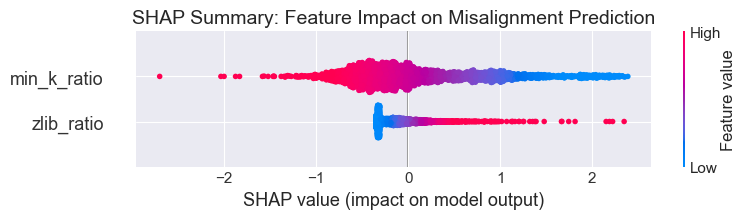

In [29]:
if shap_values is not None:
    # SHAP Summary Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_scaled, feature_names=feature_cols, show=False)
    plt.title('SHAP Summary: Feature Impact on Misalignment Prediction', fontsize=14)
    plt.tight_layout()
    plt.savefig('figures/shap_summary.png', dpi=300, bbox_inches='tight')
    print("✅ SHAP summary saved to figures/shap_summary.png")
    plt.show()

✅ SHAP importance saved to figures/shap_importance.png


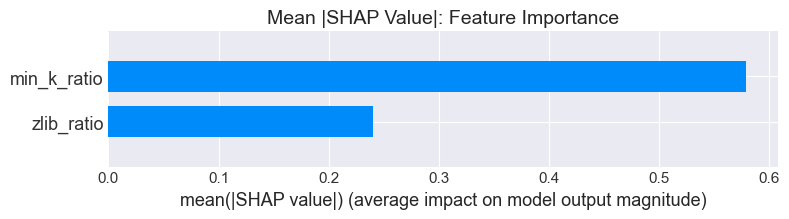


Feature Importance Ranking:
    Feature  Mean |SHAP|
min_k_ratio     0.579122
 zlib_ratio     0.240573


In [30]:
if shap_values is not None:
    # SHAP Bar Plot
    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_values, X_scaled, feature_names=feature_cols, 
                      plot_type="bar", show=False)
    plt.title('Mean |SHAP Value|: Feature Importance', fontsize=14)
    plt.tight_layout()
    plt.savefig('figures/shap_importance.png', dpi=300, bbox_inches='tight')
    print("✅ SHAP importance saved to figures/shap_importance.png")
    plt.show()
    
    # Feature importance ranking
    mean_shap = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Mean |SHAP|': mean_shap
    }).sort_values('Mean |SHAP|', ascending=False)
    
    print("\nFeature Importance Ranking:")
    print(importance_df.to_string(index=False))

---
## Part 3: Final Summary
---

In [31]:
# Generate comprehensive summary
print("=" * 80)
print("FINAL SUMMARY: MIA-MISALIGNMENT ANALYSIS")
print("=" * 80)

print(f"\n📊 DATA SUMMARY")
print(f"   Datasets analyzed: {len(all_stats_conditioned)}")
print(f"   Total samples: {len(results_df_clean)}")

print(f"\n📈 CORRELATION RESULTS (Dataset-Level)")
for feature in feature_cols:
    r, p = stats.pearsonr(dataset_agg['misalignment_score'], dataset_agg[feature])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"   {feature}: r = {r:.4f}, p = {p:.6f} {sig}")

print(f"\n🎯 ROC/AUC RESULTS")
for feature, data in roc_results.items():
    print(f"   {feature}: AUC = {data['auc']:.4f}")

print(f"\n🔄 CROSS-VALIDATION (Best Classifier)")
best_clf = max(cv_results.items(), key=lambda x: x[1]['roc_auc_mean'])
print(f"   {best_clf[0]}: ROC AUC = {best_clf[1]['roc_auc_mean']:.4f} ± {best_clf[1]['roc_auc_std']:.4f}")

# Determine conclusion
best_corr = max([abs(stats.pearsonr(dataset_agg['misalignment_score'], dataset_agg[f])[0]) for f in feature_cols])
best_auc = max([roc_results[f]['auc'] for f in feature_cols])

print(f"\n🏆 VERDICT")
if best_corr > 0.5 and best_auc > 0.65:
    print("   ✅ STRONG EVIDENCE: Misalignment correlates with MIA vulnerability")
elif best_corr > 0.3 or best_auc > 0.55:
    print("   ⚠️  MODERATE EVIDENCE: Some correlation found, needs more investigation")
else:
    print("   ❌ WEAK EVIDENCE: No strong correlation found")

print("\n" + "=" * 80)

FINAL SUMMARY: MIA-MISALIGNMENT ANALYSIS

📊 DATA SUMMARY
   Datasets analyzed: 10
   Total samples: 2500

📈 CORRELATION RESULTS (Dataset-Level)
   min_k_ratio: r = -0.5161, p = 0.126736 ns
   zlib_ratio: r = -0.3040, p = 0.393186 ns

🎯 ROC/AUC RESULTS
   min_k_ratio: AUC = 0.6180
   zlib_ratio: AUC = 0.6049

🔄 CROSS-VALIDATION (Best Classifier)
   Gradient Boosting: ROC AUC = 0.6459 ± 0.0248

🏆 VERDICT
   ⚠️  MODERATE EVIDENCE: Some correlation found, needs more investigation



In [32]:
# Save all results
import pickle

# Save extended results
results_df_clean.to_csv('results/mia_misalignment_full_results.csv', index=False)

# Save summary statistics
summary_dict = {
    'correlation_results': correlation_results,
    'roc_results': {k: {'auc': v['auc'], 'inverted': v['inverted']} for k, v in roc_results.items()},
    'cv_results': cv_results,
    'dataset_aggregated': dataset_agg.to_dict(),
}

with open('results/analysis_summary.pkl', 'wb') as f:
    pickle.dump(summary_dict, f)

print("✅ All results saved!")
print("\n📁 Output files:")
print("   - results/mia_misalignment_full_results.csv")
print("   - results/analysis_summary.pkl")
print("   - figures/correlation_scatter.png")
print("   - figures/roc_auc_analysis.png")
print("   - figures/kfold_cv_results.png")
print("   - figures/shap_summary.png")
print("   - figures/shap_importance.png")

✅ All results saved!

📁 Output files:
   - results/mia_misalignment_full_results.csv
   - results/analysis_summary.pkl
   - figures/correlation_scatter.png
   - figures/roc_auc_analysis.png
   - figures/kfold_cv_results.png
   - figures/shap_summary.png
   - figures/shap_importance.png
